<a href="https://colab.research.google.com/github/radhikasset-prog/DSU-FDP-Data-Analytics-day1/blob/main/Stud%20slot%20details.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 12 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   Timestamp                                           78 non-null     object
 1   Email address                                       78 non-null     object
 2   Name of the student with Initial [Ex: Radhika S ]   78 non-null     object
 3   Regno [ ex:  11523100078 ]                          78 non-null     int64 
 4   Hostel/Dayscholar                                   78 non-null     object
 5   University Transport (Yes/No)                       78 non-null     object
 6   If yes for University Transport Boarding Point      33 non-null     object
 7   if University Bus, BUS NO[ Ex: C1 ]                 32 non-null     object
 8   If Dayscholar Distance in Km                        78 non-null     obj

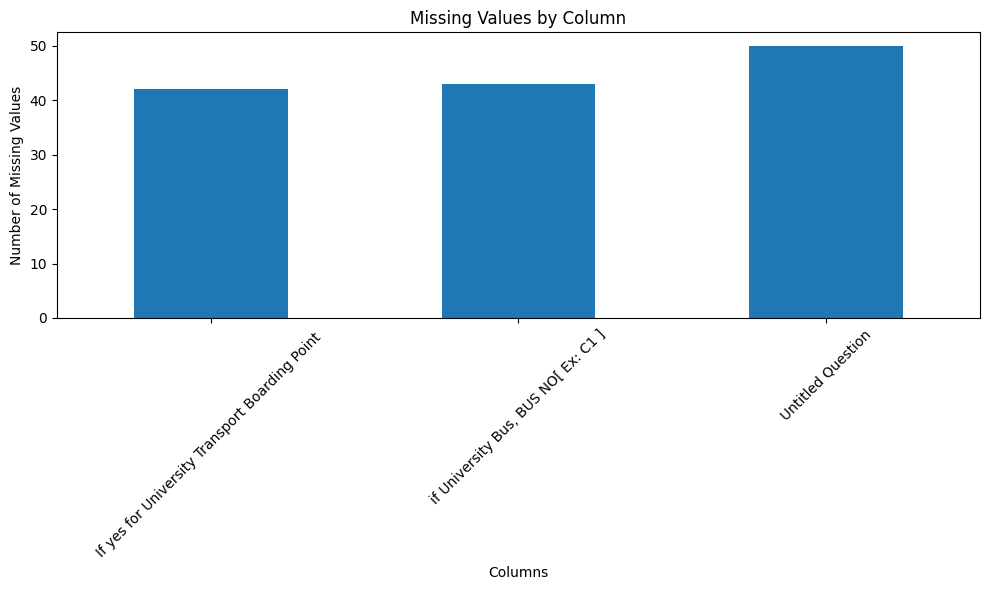

Number of students using the university bus: 19
File saved successfully as 'university_bus_users.csv'
Number of university bus users: 19
Number of hostel students: 3
File saved successfully as 'hostel_users.csv'


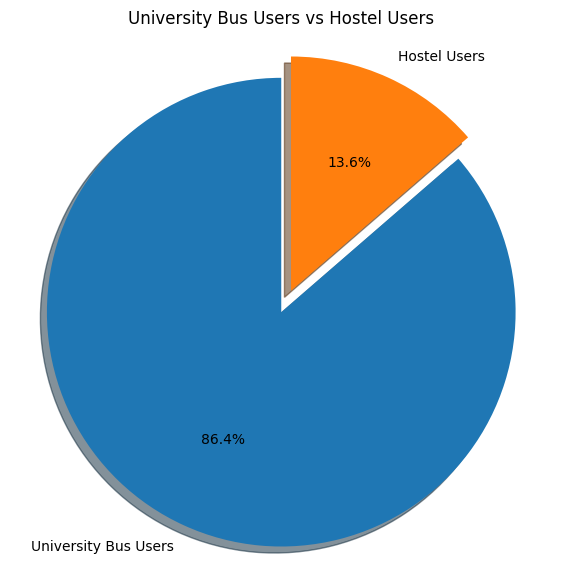

Total Students : 73
Slot 1 Students: 61
Slot 2 Students: 12

Files saved successfully:
slot1_student_list.csv
slot2_student_list.csv
Slot 1 Students: 61
Slot 2 Students: 12


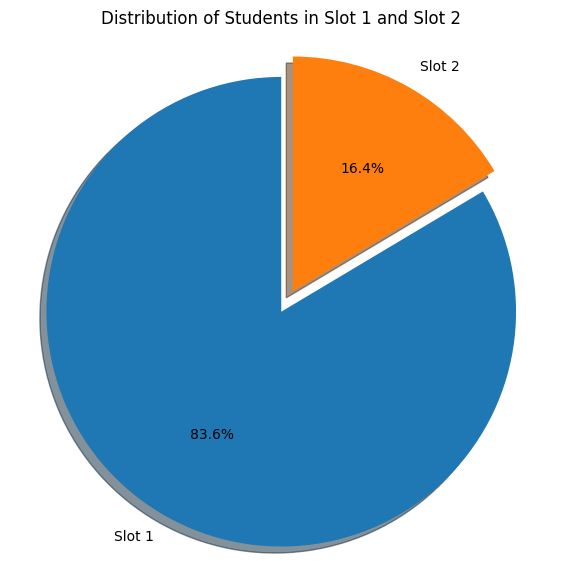

In [38]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
#using Google Colab, to download the file automatically
from google.colab import files

# Load dataset
df = pd.read_csv("studtransportIT.csv")
#print("First 5 Records:")
#print(df.head())


#To Print dataset Information about missing values
print("\nDataset Information")
print(df.info())
print("\nMissing Values")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# to identify whether duplicates are removed or not
print("\nDataset Information")
print(df.info())

# The Dataset have duplicates ,but not exactly same in all column data so its not considered ,its not removed,it shows same information
#to remove duplicate i used Regno as  primary key
df = df.drop_duplicates(subset='Regno [ ex:  11523100078 ]', keep='first')

# To identify whether duplicates are removed or not ,recheck
print("\nDataset Information")
print(df.info())

#WE can check through summaraised content
print("Duplicates removed successfully!")
print("Total records:", len(df))

#To download and save file as csv after removing duplicates
# Save as CSV
output_file = "studtransportIT_no_duplicates.csv"
df.to_csv(output_file, index=False)
print(f"Cleaned file saved as: {output_file}")

#using Google Colab, to download the file automatically
#//files.download("studtransportIT_no_duplicates.csv")

#Count missing values in each column
print(df.isnull().sum())

#Show only columns that have missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Columns with missing values:")
print(missing)



# Ploting to show missing values
# Plot
plt.figure(figsize=(10, 6))
missing.sort_values().plot(kind='bar')

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


# Replace all missing values with 'NULL'
df = df.fillna("NULL")


# Remove the 'Unnamed: 0' column
#df = df.drop(columns=["Untitled Question: 0"])

# Save the updated dataset
df.to_csv("studtransportIT_null_filled.csv", index=False)

#using Google Colab, to download the file automatically
#//files.download("studtransportIT_null_filled.csv")

# Count students using the university bus
bus_count = (df["University Transport (Yes/No)"] == "Yes").sum()

print("Number of students using the university bus:", bus_count)



#university Bus User File
# Filter students who use the university bus
bus_users = df[df["University Transport (Yes/No)"] == "Yes"]

# Save to a new CSV file
bus_users.to_csv("studtransportuniversity_bus_users.csv", index=False)

print("File saved successfully as 'university_bus_users.csv'")
print("Number of university bus users:", len(bus_users))

#Hostel user file
# Filter hostel students
hostel_students = df[df["Hostel/Dayscholar"] == "University Hostel"]

# Count hostel students
hostel_count = len(hostel_students)
print("Number of hostel students:", hostel_count)

# Save hostel students to a new CSV file
hostel_students.to_csv("studtransport_hostel_users.csv", index=False)

print("File saved successfully as 'hostel_users.csv'")


#Pie chart about Trasport users
# Count University Bus users
bus_count = (df["University Transport (Yes/No)"] == "Yes").sum()

# Count Hostel users
hostel_count = (df["Hostel/Dayscholar"] == "University Hostel").sum()

# Data for pie chart
labels = ["University Bus Users", "Hostel Users"]
sizes = [bus_count, hostel_count]

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=(0.05, 0.05)  # Slightly separate both slices
)

plt.title("University Bus Users vs Hostel Users")
plt.axis('equal')  # Makes the pie chart circular
plt.show()


# Create Slot 2 list

# Convert distance column to numeric
df["If Dayscholar Distance in Km"] = pd.to_numeric(
    df["If Dayscholar Distance in Km"],
    errors="coerce"
)
slot2 = df[
    (df["If Dayscholar Distance in Km"] < 10) &
    (df["University Transport (Yes/No)"].str.strip().str.lower() == "no")
]



# Create Slot 1 list (remaining students)
slot1 = df.drop(slot2.index)

# Save the files as slot1list and slot2
slot1.to_csv("slot1_student_list.csv", index=False)
slot2.to_csv("slot2_student_list.csv", index=False)

# Display counts
print("Total Students :", len(df))
print("Slot 1 Students:", len(slot1))
print("Slot 2 Students:", len(slot2))

print("\nFiles saved successfully:")
print("slot1_student_list.csv")
print("slot2_student_list.csv")


# Count students in each slot
slot1_count = len(slot1)
slot2_count = len(slot2)

print("Slot 1 Students:", slot1_count)
print("Slot 2 Students:", slot2_count)

# Pie chart to represent slot1 and slot2 details
plt.figure(figsize=(7,7))
plt.pie(
    [slot1_count, slot2_count],
    labels=["Slot 1", "Slot 2"],
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    explode=(0.05, 0.05)
)

plt.title("Distribution of Students in Slot 1 and Slot 2")
plt.axis("equal")
plt.show()
